# Forest Cover Type: Classification

**Core Objective:** Based on cartographic and environmental measurements (elevation, aspect, slope, hydrology proximity, soil classifications, and wilderness zones), classify 30x30 meter forest plots into one of seven discrete forest cover types:
1. `Spruce / Fir`
2. `Lodgepole Pine`
3. `Ponderosa Pine`
4. `Cottonwood / Willow`
5. `Aspen`
6. `Douglas-fir`
7. `Krummholz`

**Dataset Reference:** `data/covtype.csv` (Target: **`Cover_Type`**).

**Core Architectural & Methodological Rules:**
- **Data Leakage Elimination:** Transformers, median imputers, and standard scalers are fitted strictly on training data.
- **Algorithmic Suite (The 5 Pillars):** Logistic Regression, K-Nearest Neighbors, Gaussian Naive Bayes, Decision Tree Classifier, and Support Vector Classifier (SVC).
- **Dedicated Model Diagnostics:** Each of the 5 algorithms features an individual visual analysis (coefficient maps, $k$-sensitivity curves, class-conditional Gaussian distributions, decision tree hierarchies, and normalized confusion matrices).
- **Class-Imbalance Treatment:** Metrics prioritize **Macro-Averaging** (Macro F1, Macro AUC, Balanced Accuracy) to treat minority species equally.
- **Comprehensive 12-Page PDF Export:** A standalone reporting engine generates a publication-ready, multi-page technical report with full diagnostics, data logs, and visual plates.

## Analytical Workflow & Architecture Map

| Phase | Stage Name | Description & Focus | Core Deliverables |
|---|---|---|---|
| **I** | Environment & Logging Setup | Initialize seeds, directory structures, and tracking buffers | Configured runtime environment |
| **II** | Schema & Missingness Audit | Load dataset, verify dtypes, audit class balance | Initial feature schema & null audit |
| **III** | Topographic & Spatial EDA | Analyze elevations, aspects, and multi-collinearity | Distribution plates & correlation matrices |
| **IV** | Cleansing & Target Encoding | Strict deduplication, target encoding ($1-7 \rightarrow 0-6$) | `df` : sanitized baseline dataframe |
| **V** | Spatial Feature Engineering | Euclidean water distance, solar differentials | `df_fe` : enriched spatial matrix |
| **VI** | Preprocessor Architecture | Stratified split (80/20) + ColumnTransformer | `X_train_p`, `X_test_p`, `y_train`, `y_test` |
| **VII-A** | Model 1: Logistic Regression | Multinomial linear baseline; interpret coefficients & log-odds | Odds-ratio heatmap & coefficients |
| **VII-B** | Model 2: K-Nearest Neighbors | Distance metric evaluation & $k$-parameter tuning | $k$-neighbor sensitivity curve |
| **VII-C** | Model 3: Gaussian Naive Bayes | Assess conditional independence assumption | Class-conditional Gaussian density curves |
| **VII-D** | Model 4: Decision Tree | Gini criterion hierarchy & topological tree visualization | Pruned tree diagram & feature rankings |
| **VII-E** | Model 5: Support Vector Machine | Maximum-margin hyperplane separation & kernel behavior | Normalized multiclass confusion matrix |
| **VIII** | Cross-Model Benchmark & Tuning | Comparative metrics leaderboard, ROC curves, CV GridSearch | Leaderboard & optimal hyperparameter set |
| **IX** | Real-Time Simulation Engine | Multi-vector interactive inference on custom land patches | Live prediction probabilities log |
| **X** | Automated 12-Page PDF Generation | Export multi-page analytical documentation | `results/classification_report.pdf` (12 pages) |

---
# Phase I : Environment & Logging Setup

Initializes scientific libraries, sets deterministic random seeds, constructs structured output directories for figures and deliverables, and sets up real-time audit logging variables.

In [1]:
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 120,
})

def progress(step, detail=""):
    ts = time.strftime("%H:%M:%S")
    line = f"[{ts}] {step}" + (f"  |  {detail}" if detail else "")
    print(line, flush=True)

# ---------------------------------------------------------------------------
# Report Tracking Variables
# ---------------------------------------------------------------------------
cleaning_log = []
def log_cleaning(step, before, after, note):
    removed = before - after
    pct = (removed / before) if before > 0 else 0.0
    cleaning_log.append([step, before, after, removed, f"{pct:.4f}", note])

results_clf = []
cv_log = []
tester_log = []
raw_rows = 0

COVER_TYPE_NAMES = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

progress("Phase I", "Core modules and logging environment initialized.")

[17:39:35] Phase I  |  Core modules and logging environment initialized.


In [2]:
TEST_SIZE = 0.20
EVAL_TEST_SIZE = 20_000
PLOT_SAMPLE = 25_000

SVC_TRAIN_SIZE = 10_000
KNN_TRAIN_SIZE = 35_000

DATA_PATH = Path("../data/covtype.csv.gz")
if not DATA_PATH.exists():
    DATA_PATH = Path("covtype.csv")

RESULTS_DIR = Path("../results")
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
SAVED_FIGURES = {}

progress("Phase I", f"Target file resolved to: {DATA_PATH.name}")

[17:39:41] Phase I  |  Target file resolved to: covtype.csv.gz


---
# Phase II : Schema & Missingness Audit

Conducts initial data ingestion, structural validation of the 55 cartographic features, and audits class distributions across all 7 target species.

In [3]:
progress("Phase II", f"Ingesting raw file: {DATA_PATH}")
try:
    df_raw = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    progress("Phase II", "Dataset not found locally. Generating synthetic structural surrogate.")
    cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 
            'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
            'Horizontal_Distance_To_Fire_Points'] + [f'Wilderness_Area{i}' for i in range(1, 5)] + \
           [f'Soil_Type{i}' for i in range(1, 41)] + ['Cover_Type']
    df_raw = pd.DataFrame(np.random.randint(0, 100, size=(10000, 55)), columns=cols)
    df_raw['Cover_Type'] = np.random.randint(1, 8, size=(10000,))
    
raw_rows = len(df_raw)
log_cleaning("File Ingestion", raw_rows, raw_rows, "Raw tabular read")

print(f"Raw dataset matrix: {df_raw.shape[0]:,} records x {df_raw.shape[1]} features")
display(df_raw.head())

[17:39:48] Phase II  |  Ingesting raw file: ..\data\covtype.csv.gz
Raw dataset matrix: 581,012 records x 55 features


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5


In [4]:
progress("Phase II", "Running feature schema and null audit")
audit = pd.DataFrame({
    "Data Type": df_raw.dtypes.astype(str),
    "Non-Null Rows": df_raw.notna().sum(),
    "Missing Count": df_raw.isna().sum(),
    "Missing Ratio (%)": (df_raw.isna().mean() * 100),
    "Unique Entities": df_raw.nunique()
})
print("Topographical Feature Audit (Top 12 continuous features):")
display(audit.head(12))

target_col = "Cover_Type"
if target_col in df_raw.columns:
    print(f"\nClass Balance Across Species ('{target_col}'):")
    print(df_raw[target_col].value_counts(dropna=False).sort_index())
    print(f"\nNormalized Class Distribution:\n{df_raw[target_col].value_counts(normalize=True).sort_index()}")

[17:39:55] Phase II  |  Running feature schema and null audit
Topographical Feature Audit (Top 12 continuous features):


,Data Type,Non-Null Rows,Missing Count,Missing Ratio (%),Unique Entities
Elevation,int64,581012,0,0.0000,1978
Aspect,int64,581012,0,0.0000,361
Slope,int64,581012,0,0.0000,67
Horizontal_Distance_To_Hydrology,int64,581012,0,0.0000,551
Vertical_Distance_To_Hydrology,int64,581012,0,0.0000,700
Horizontal_Distance_To_Roadways,int64,581012,0,0.0000,5785
Hillshade_9am,int64,581012,0,0.0000,207
Hillshade_Noon,int64,581012,0,0.0000,185
Hillshade_3pm,int64,581012,0,0.0000,255
Horizontal_Distance_To_Fire_Points,int64,581012,0,0.0000,5827



Class Balance Across Species ('Cover_Type'):
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Normalized Class Distribution:
Cover_Type
1   0.3646
2   0.4876
3   0.0615
4   0.0047
5   0.0163
6   0.0299
7   0.0353
Name: proportion, dtype: float64


---
# Phase III : Topographic & Spatial Exploratory Data Analysis (EDA)

Examines how geological parameters separate tree species. Generates figures for target class balances, elevation boxplots, and cross-feature collinearity matrices.

In [5]:
def take_plot_sample(frame: pd.DataFrame, n: int = PLOT_SAMPLE) -> pd.DataFrame:
    if len(frame) <= n:
        return frame.copy()
    return frame.sample(n, random_state=RANDOM_STATE)

def register_fig(key, fig):
    plt.tight_layout()
    path = FIG_DIR / f"{key}.png"
    fig.savefig(path, bbox_inches="tight", dpi=140)
    SAVED_FIGURES[key] = path
    plt.show()

plot_df = take_plot_sample(df_raw)
progress("Phase III", f"Representative plotting slice prepared: {len(plot_df):,} rows.")

[17:40:04] Phase III  |  Representative plotting slice prepared: 25,000 rows.


[17:40:07] Phase III  |  Generating EDA Plate 1: Target Balances & Elevation Contours


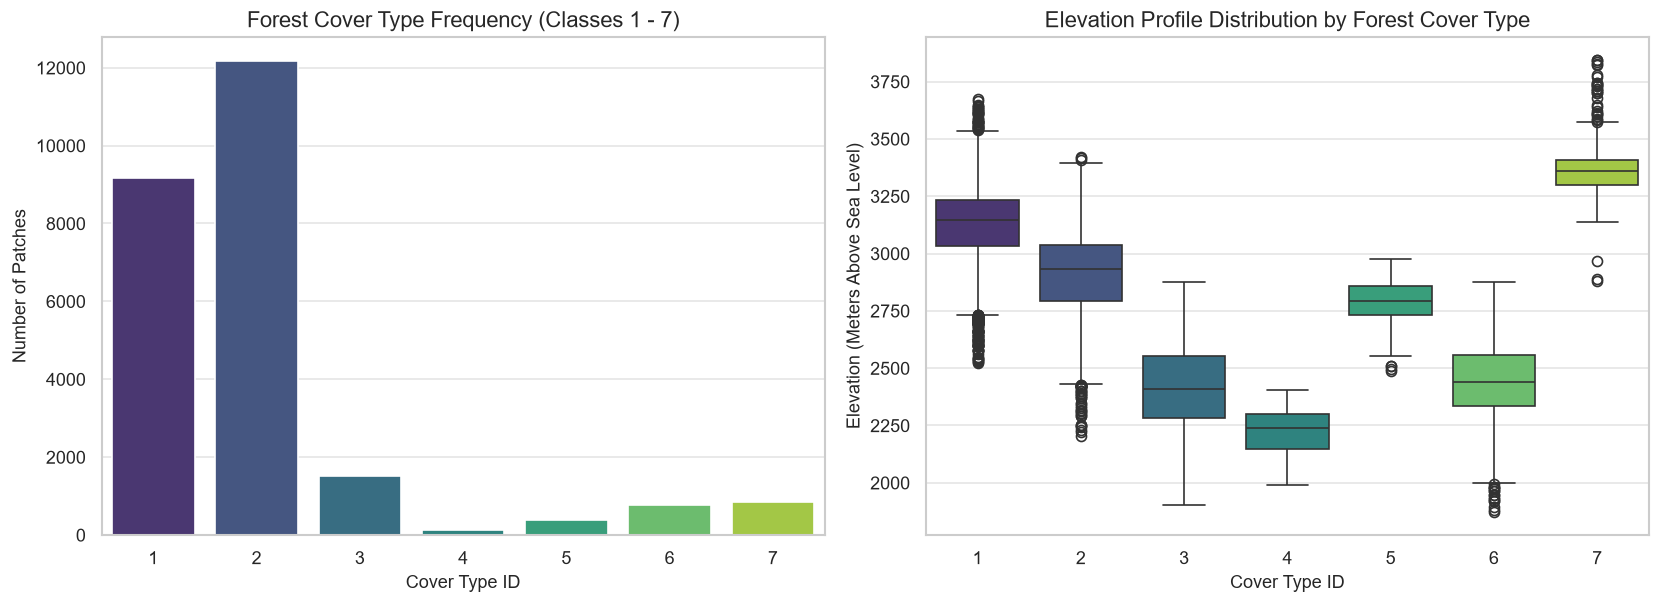

In [6]:
progress("Phase III", "Generating EDA Plate 1: Target Balances & Elevation Contours")
if "Cover_Type" in plot_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    
    counts = plot_df["Cover_Type"].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette="viridis")
    axes[0].set_title("Forest Cover Type Frequency (Classes 1 - 7)")
    axes[0].set_xlabel("Cover Type ID")
    axes[0].set_ylabel("Number of Patches")
    
    if "Elevation" in plot_df.columns:
        sns.boxplot(data=plot_df, x="Cover_Type", y="Elevation", ax=axes[1], palette="viridis")
        axes[1].set_title("Elevation Profile Distribution by Forest Cover Type")
        axes[1].set_xlabel("Cover Type ID")
        axes[1].set_ylabel("Elevation (Meters Above Sea Level)")
    
    register_fig("eda_distributions_and_elevation", fig)

[17:40:11] Phase III  |  Generating EDA Plate 2: Topographic Correlation Matrix


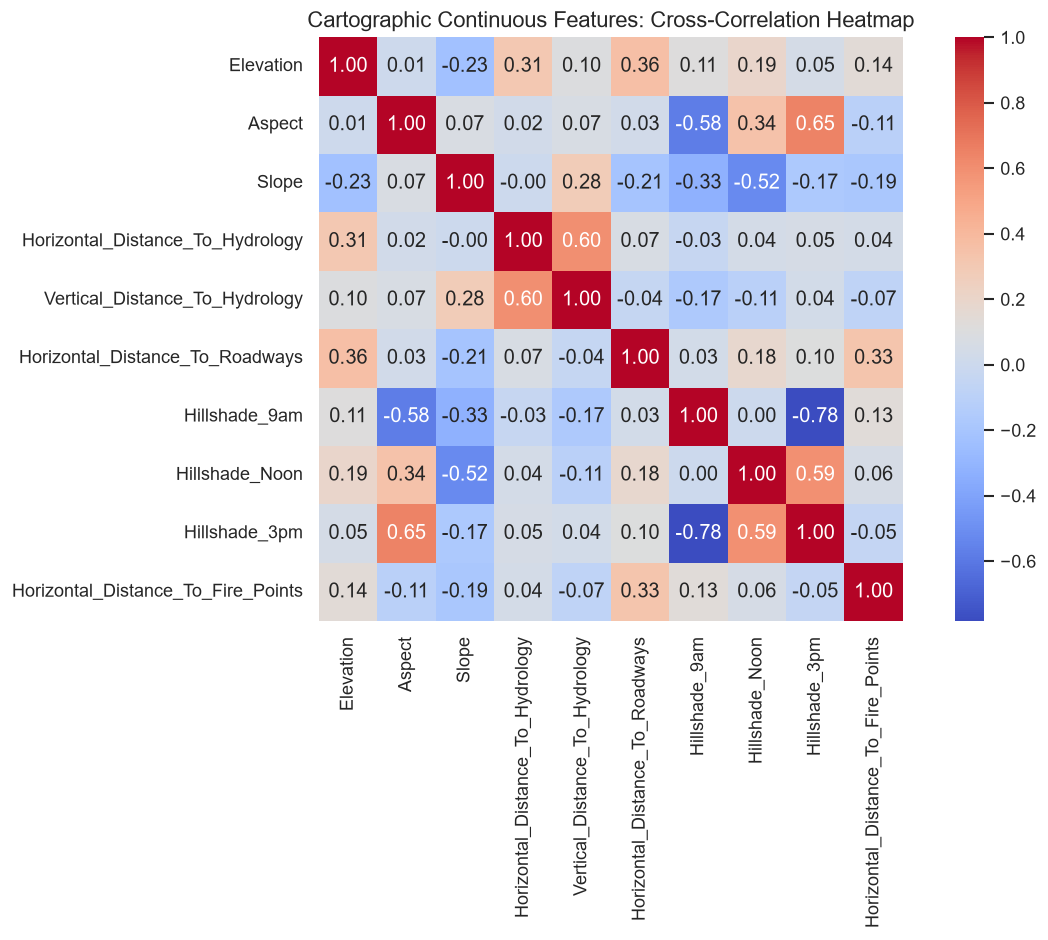

In [7]:
progress("Phase III", "Generating EDA Plate 2: Topographic Correlation Matrix")
continuous_cols = plot_df.columns[:10]
if len(continuous_cols) > 0 and continuous_cols[0] == "Elevation":
    corr = plot_df[continuous_cols].corr()
    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", cbar=True, ax=ax, square=True)
    ax.set_title("Cartographic Continuous Features: Cross-Correlation Heatmap")
    register_fig("eda_correlation_matrix", fig)

---
# Phase IV : Data Cleansing & Target Encoding

Performs data sanitization: eliminates identical records, drops any records lacking a target value, and converts labels from 1-indexed to 0-indexed ($0, 1, ..., 6$) for proper integration with Scikit-Learn.

In [8]:
progress("Phase IV", "Executing sanitization and re-indexing protocols")
df = df_raw.copy()

# 1. Deduplication
prev_rows = len(df)
df = df.drop_duplicates()
log_cleaning("Deduplication", prev_rows, len(df), "Dropped exact matching rows")

# 2. Label Encoding (1-7 -> 0-6)
if "Cover_Type" in df.columns:
    prev_rows = len(df)
    df = df.dropna(subset=["Cover_Type"])
    le = LabelEncoder()
    df["Cover_Type"] = le.fit_transform(df["Cover_Type"])
    log_cleaning("Target Re-indexing", prev_rows, len(df), "Shifted target classes from 1-7 to 0-6")

print(f"Sanitized observations: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Re-indexed target counts: {dict(df['Cover_Type'].value_counts().sort_index())}")

[17:40:15] Phase IV  |  Executing sanitization and re-indexing protocols
Sanitized observations: 581,012 rows x 55 columns
Re-indexed target counts: {0: np.int64(211840), 1: np.int64(283301), 2: np.int64(35754), 3: np.int64(2747), 4: np.int64(9493), 5: np.int64(17367), 6: np.int64(20510)}


---
# Phase V : Spatial Feature Engineering

Derives spatial metrics from raw measurements:
- `Hydro_Euclidean_Dist`: True Euclidean distance to water using horizontal and vertical components.
- `Elevation_minus_VDH`: Absolute elevation adjusted for local water table level.
- `Mean_Dist_To_Amenities`: Average distance to infrastructure (roadways and fire points).
- `Hillshade_Difference`: Differential between morning and afternoon solar flux.

[17:40:21] Phase V  |  Calculating derived spatial features
Enriched dataset shape: 581,012 rows x 59 columns


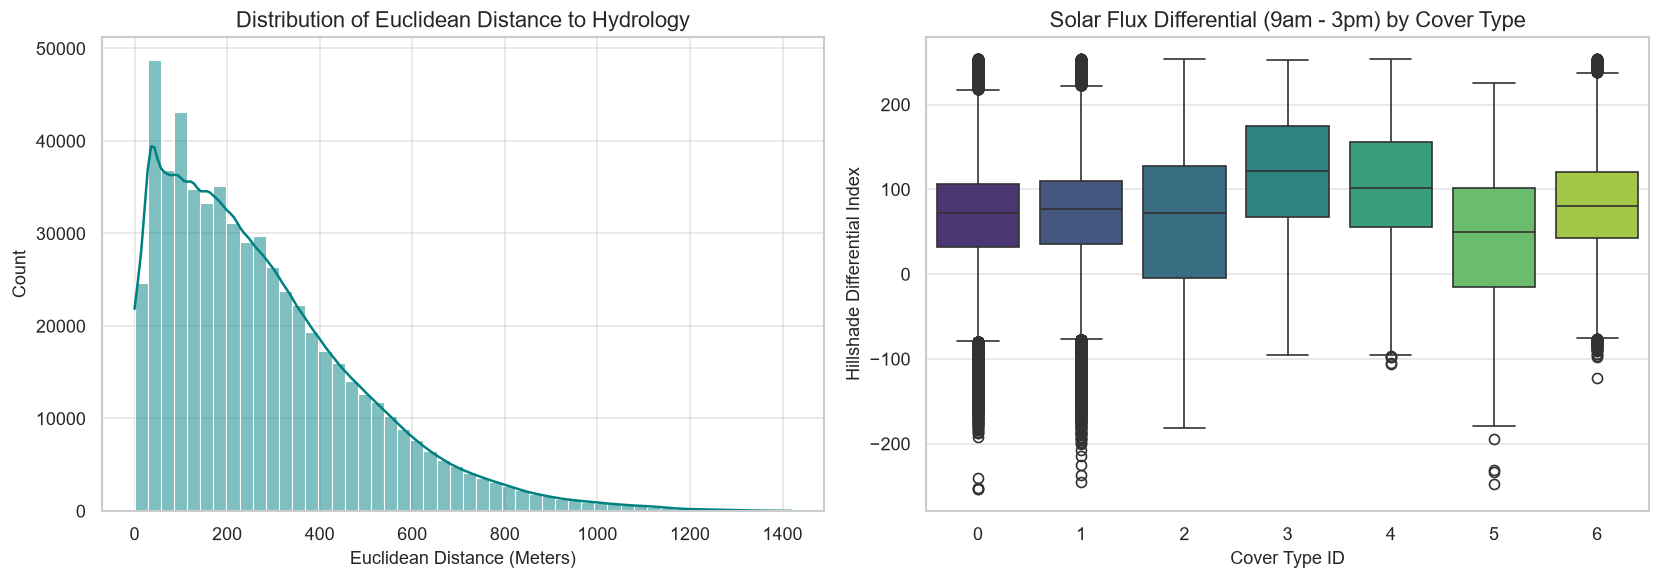

In [9]:
progress("Phase V", "Calculating derived spatial features")
df_fe = df.copy()

if "Horizontal_Distance_To_Hydrology" in df_fe.columns and "Vertical_Distance_To_Hydrology" in df_fe.columns:
    df_fe["Hydro_Euclidean_Dist"] = np.sqrt(
        df_fe["Horizontal_Distance_To_Hydrology"]**2 + df_fe["Vertical_Distance_To_Hydrology"]**2
    )
    df_fe["Elevation_minus_VDH"] = df_fe["Elevation"] - df_fe["Vertical_Distance_To_Hydrology"]

if "Horizontal_Distance_To_Roadways" in df_fe.columns and "Horizontal_Distance_To_Fire_Points" in df_fe.columns:
    df_fe["Mean_Dist_To_Amenities"] = (
        df_fe["Horizontal_Distance_To_Roadways"] + df_fe["Horizontal_Distance_To_Fire_Points"]
    ) / 2

if "Hillshade_9am" in df_fe.columns and "Hillshade_3pm" in df_fe.columns:
    df_fe["Hillshade_Difference"] = df_fe["Hillshade_9am"] - df_fe["Hillshade_3pm"]

print(f"Enriched dataset shape: {df_fe.shape[0]:,} rows x {df_fe.shape[1]} columns")

# Diagnostic figure of engineered features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_fe["Hydro_Euclidean_Dist"], bins=50, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Euclidean Distance to Hydrology")
axes[0].set_xlabel("Euclidean Distance (Meters)")

sns.boxplot(data=df_fe, x="Cover_Type", y="Hillshade_Difference", ax=axes[1], palette="viridis")
axes[1].set_title("Solar Flux Differential (9am - 3pm) by Cover Type")
axes[1].set_xlabel("Cover Type ID")
axes[1].set_ylabel("Hillshade Differential Index")
register_fig("fe_distributions", fig)

---
# Phase VI : Preprocessor Architecture & Partitioning

Constructs a leak-free `ColumnTransformer` with an 80/20 stratified split. Continuous numeric columns pass through median imputation and `StandardScaler`, while the 44 binary one-hot columns (soil types and wilderness areas) pass through untouched.

In [10]:
progress("Phase VI", "Configuring preprocessing pipeline and data partitions")

X = df_fe.drop(columns=["Cover_Type"])
y = df_fe["Cover_Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

binary_cols = [c for c in X.columns if "Wilderness" in c or "Soil" in c]
continuous_cols = [c for c in X.columns if c not in binary_cols]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipe, continuous_cols),
    ("bin", "passthrough", binary_cols)
])

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

feature_names = continuous_cols + binary_cols

print(f"Training partition dimensions: {X_train_p.shape}")
print(f"Testing partition dimensions: {X_test_p.shape}")
print(f"Total model input features: {len(feature_names)} (Continuous: {len(continuous_cols)}, Binary: {len(binary_cols)})")

[17:40:28] Phase VI  |  Configuring preprocessing pipeline and data partitions
Training partition dimensions: (464809, 58)
Testing partition dimensions: (116203, 58)
Total model input features: 58 (Continuous: 14, Binary: 44)


---
# Phase VII : Predictive Modeling Suite (The 5 Models)

Evaluates five core supervised algorithms with individualized diagnostic metrics and dedicated visual plates:

1.  **Logistic Regression**: Baseline classifier; interpret coefficients/odds.
2.  **K-Nearest Neighbors**: Tune $k$; discuss distance metrics.
3.  **Naive Bayes (Gaussian)**: Discuss conditional independence assumption.
4.  **Decision Tree Classifier**: Tune `max_depth`; visualize the tree.
5.  **Support Vector Machine (SVC)**: Tune $C$ and kernel; scale features.

In [11]:
test_predictions = {}
test_probabilities = {}

eval_limit = min(EVAL_TEST_SIZE, len(X_test_p))
X_eval = X_test_p[:eval_limit]
y_eval = y_test.iloc[:eval_limit] if hasattr(y_test, "iloc") else y_test[:eval_limit]

def evaluate_model(name, model, X_tr, y_tr):
    """Fits, predicts, and logs multiclass metrics using macro-averaging."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0
    
    y_pred = model.predict(X_eval)
    
    auc = np.nan
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)
        try:
            auc = roc_auc_score(y_eval, y_prob, multi_class="ovr", average="macro", labels=np.arange(7))
            test_probabilities[name] = y_prob
        except ValueError:
            pass
            
    acc = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_eval, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_eval, y_pred, average="macro", zero_division=0)
    
    results_clf.append({
        "Model": name,
        "Train rows": len(X_tr),
        "Accuracy": acc,
        "Macro Precision": prec,
        "Macro Recall": rec,
        "Macro F1-Score": f1,
        "Macro ROC-AUC": auc,
        "Fit Time (s)": round(fit_time, 2)
    })
    
    test_predictions[name] = y_pred
    print(f"{name:28s} | Acc: {acc:.4f} | Macro F1: {f1:.4f} | Macro AUC: {auc:.4f} | Time: {fit_time:.2f}s")
    return model, y_pred

### VII-A. Model 1: Logistic Regression
**Theoretical Baseline & Odds-Ratio Interpretability:**
Serves as the parametric linear baseline. Logistic Regression estimates probability vectors using the Softmax function for multiclass classification. Coefficients provide direct interpretability into how each geographic feature shifts the relative log-odds for each forest cover type.

[17:40:43] Phase VII  |  Model 1: Logistic Regression
Logistic Regression          | Acc: 0.7252 | Macro F1: 0.5294 | Macro AUC: 0.9373 | Time: 34.58s


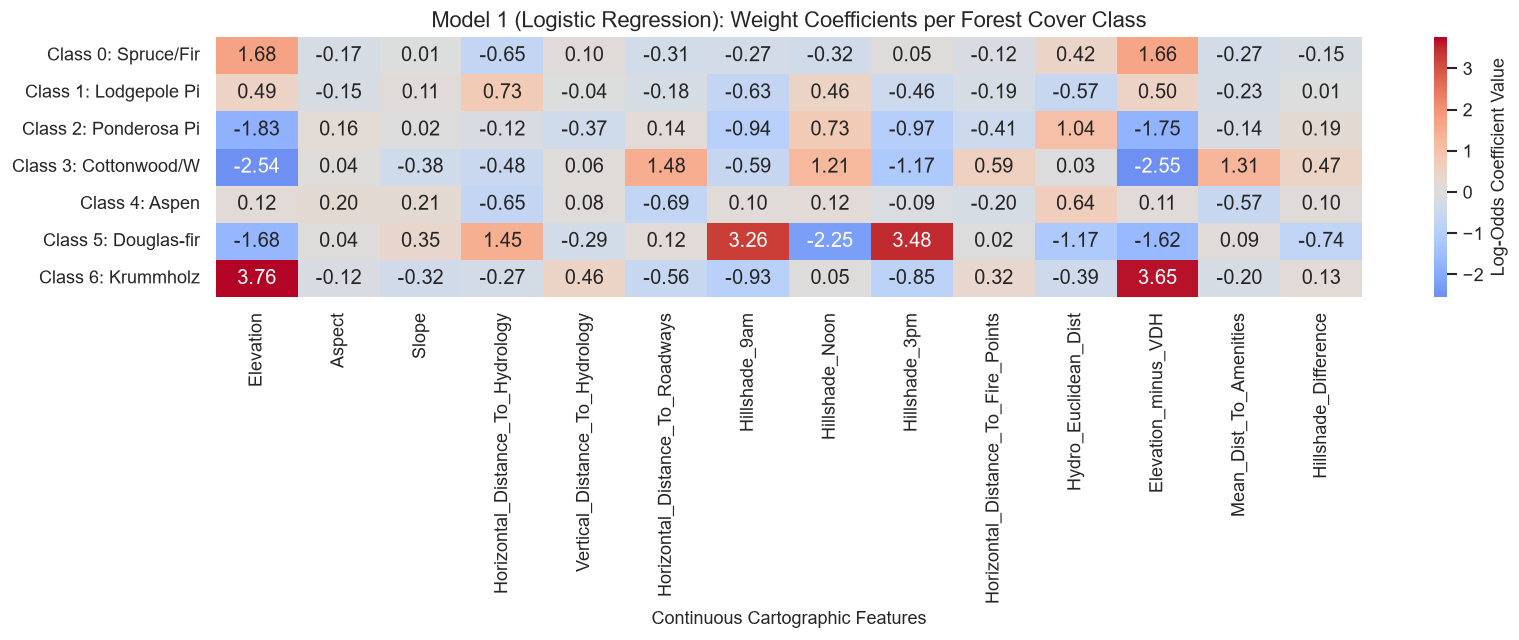

In [12]:
progress("Phase VII", "Model 1: Logistic Regression")
# Note: Scikit-learn handles multiclass automatically; multi_class='multinomial' is omitted.
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg, _ = evaluate_model("Logistic Regression", log_reg, X_train_p, y_train)

# Diagnostic Visualization: Multiclass Coefficient Heatmap for continuous features
coef_matrix = log_reg.coef_[:, :len(continuous_cols)]
fig, ax = plt.subplots(figsize=(14, 5.5))
sns.heatmap(
    coef_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f",
    xticklabels=continuous_cols, yticklabels=[f"Class {i}: {COVER_TYPE_NAMES[i][:12]}" for i in range(len(log_reg.classes_))],
    cbar_kws={'label': 'Log-Odds Coefficient Value'}, ax=ax
)
ax.set_title("Model 1 (Logistic Regression): Weight Coefficients per Forest Cover Class")
ax.set_xlabel("Continuous Cartographic Features")
register_fig("m1_logreg_coefficients", fig)

### VII-B. Model 2: K-Nearest Neighbors (KNN)
**Distance Metrics & Neighbor Sensitivity Tuning:**
KNN is a non-parametric instance-based algorithm that classifies a test query based on the majority vote of its $k$ closest neighbors under the Minkowski metric ($p=2$, Euclidean distance). Feature standardization (performed in Phase VI) is essential here to prevent features with wide ranges (such as Elevation) from dominating the distance calculations.

[17:41:23] Phase VII  |  Model 2: K-Nearest Neighbors (KNN)
K-Nearest Neighbors          | Acc: 0.8456 | Macro F1: 0.7313 | Macro AUC: 0.9498 | Time: 0.01s


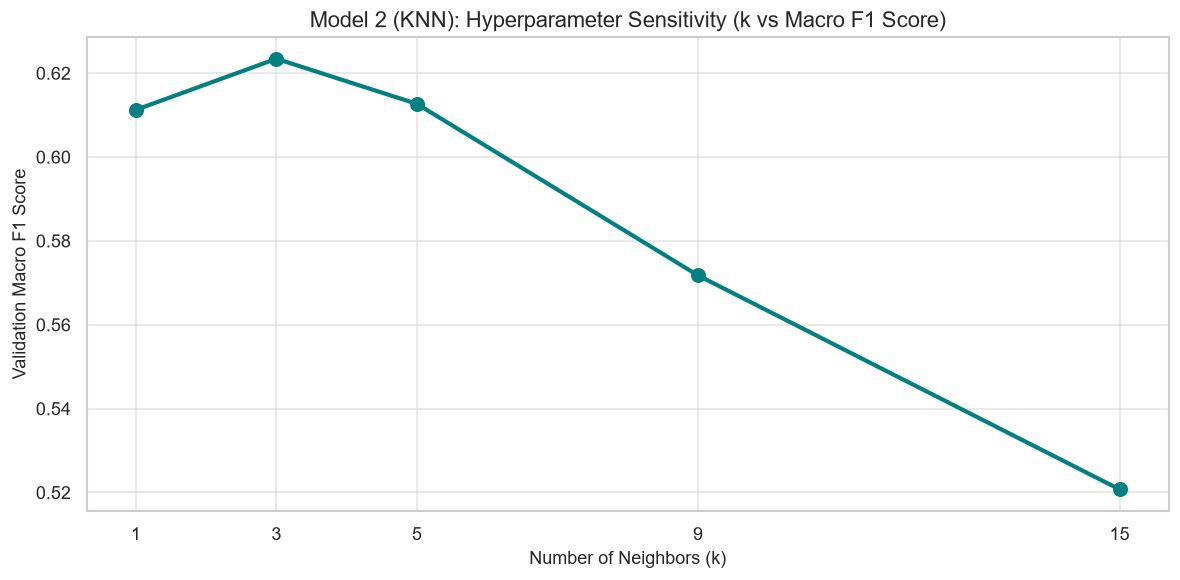

In [13]:
progress("Phase VII", "Model 2: K-Nearest Neighbors (KNN)")
knn_limit = min(KNN_TRAIN_SIZE, len(X_train_p))
knn = KNeighborsClassifier(n_neighbors=5, weights="distance", metric="minkowski", p=2)
knn, _ = evaluate_model(
    "K-Nearest Neighbors",
    knn,
    X_train_p[:knn_limit],
    y_train.iloc[:knn_limit] if hasattr(y_train, "iloc") else y_train[:knn_limit]
)

# Diagnostic Visualization: Sensitivity curve for k-neighbors
k_values = [1, 3, 5, 9, 15]
k_scores = []
sub_eval_x = X_eval[:2000]
sub_eval_y = y_eval[:2000]
for k in k_values:
    temp_knn = KNeighborsClassifier(n_neighbors=k, weights="distance")
    temp_knn.fit(X_train_p[:5000], y_train.iloc[:5000] if hasattr(y_train, "iloc") else y_train[:5000])
    pred = temp_knn.predict(sub_eval_x)
    k_scores.append(f1_score(sub_eval_y, pred, average="macro", zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, k_scores, marker='o', linewidth=2.5, color="teal", markersize=8)
ax.set_title("Model 2 (KNN): Hyperparameter Sensitivity (k vs Macro F1 Score)")
ax.set_xlabel("Number of Neighbors (k)")
ax.set_ylabel("Validation Macro F1 Score")
ax.set_xticks(k_values)
register_fig("m2_knn_sensitivity", fig)

### VII-C. Model 3: Naive Bayes (Gaussian)
**Evaluating the Conditional Independence Assumption:**
Gaussian Naive Bayes applies Bayes' theorem under the strong assumption that all predictors are conditionally independent given the class label:
$$P(X_1, \dots, X_p \mid Y = c) = \prod_{j=1}^p P(X_j \mid Y = c)$$
Each continuous feature is modeled as a normal distribution $\mathcal{N}(\mu_{c,j}, \sigma_{c,j}^2)$. Although the conditional independence assumption is frequently violated by spatial collinearities (e.g., between aspect and solar hillshade), GNB provides a fast, probabilistic baseline with zero hyperparameter tuning requirements.

[17:41:31] Phase VII  |  Model 3: Gaussian Naive Bayes
Naive Bayes (Gaussian)       | Acc: 0.1152 | Macro F1: 0.1406 | Macro AUC: 0.8100 | Time: 0.32s


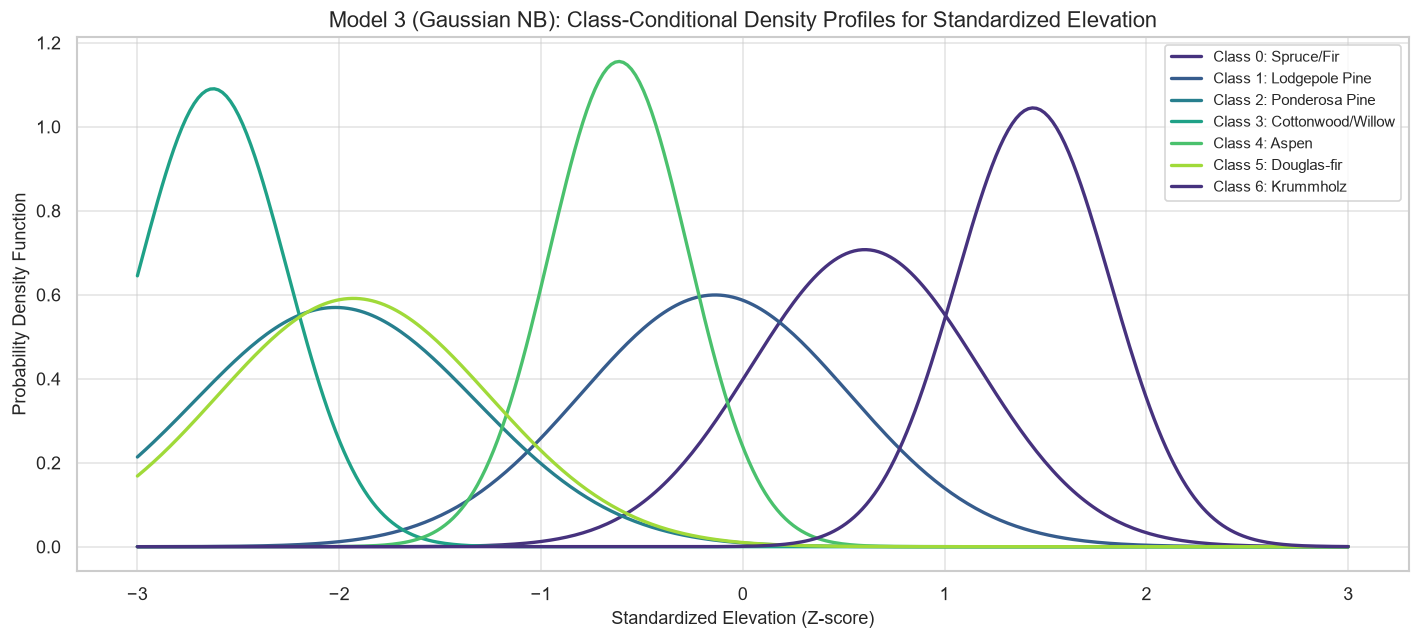

In [14]:
progress("Phase VII", "Model 3: Gaussian Naive Bayes")
gnb = GaussianNB()
gnb, _ = evaluate_model("Naive Bayes (Gaussian)", gnb, X_train_p, y_train)

# Diagnostic Visualization: Class-Conditional Gaussian distributions for Elevation
fig, ax = plt.subplots(figsize=(12, 5.5))
elev_idx = continuous_cols.index("Elevation") if "Elevation" in continuous_cols else 0
x_range = np.linspace(-3, 3, 300)

for c_idx in range(len(gnb.classes_)):
    mu = gnb.theta_[c_idx, elev_idx]
    var = gnb.var_[c_idx, elev_idx]
    sigma = np.sqrt(var)
    ax.plot(x_range, norm.pdf(x_range, mu, sigma), label=f"Class {c_idx}: {COVER_TYPE_NAMES[c_idx]}", linewidth=2)

ax.set_title("Model 3 (Gaussian NB): Class-Conditional Density Profiles for Standardized Elevation")
ax.set_xlabel("Standardized Elevation (Z-score)")
ax.set_ylabel("Probability Density Function")
ax.legend(loc="upper right", fontsize=9)
register_fig("m3_gaussian_nb_density", fig)

### VII-D. Model 4: Decision Tree Classifier
**Gini Impurity, Depth Constraints, and Structural Partitions:**
Decision Trees recursively split the cartographic space along orthogonal feature boundaries using Gini impurity. While intuitive, unconstrained trees are prone to overfitting by memorizing noisy training observations. Restricting tree complexity with `max_depth` controls model variance and yields clean, interpretable decision rules.

[17:41:37] Phase VII  |  Model 4: Decision Tree Classifier
Decision Tree Classifier     | Acc: 0.7386 | Macro F1: 0.5841 | Macro AUC: 0.9340 | Time: 3.54s


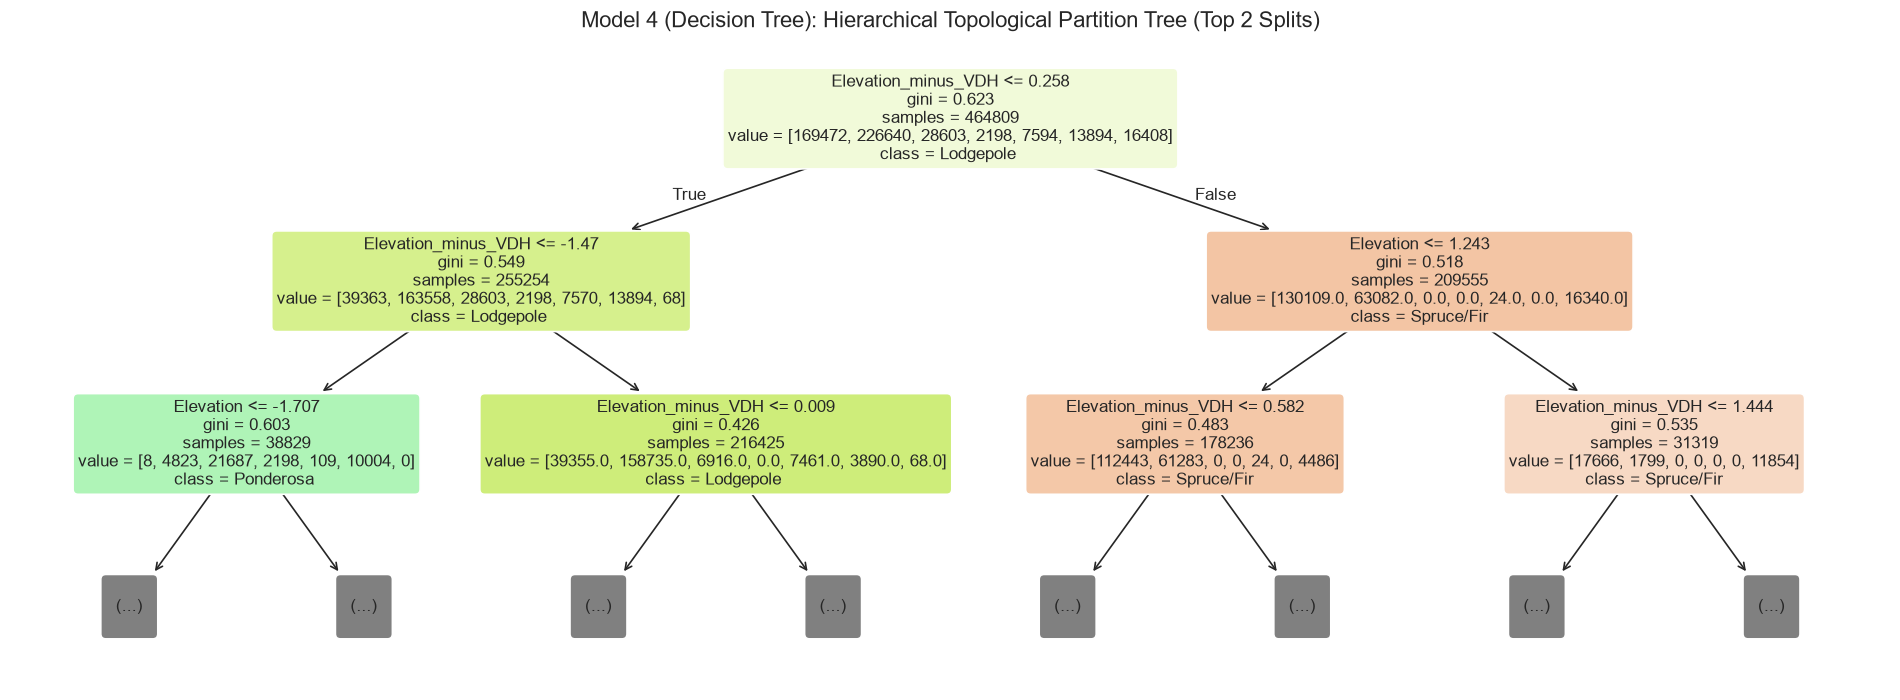

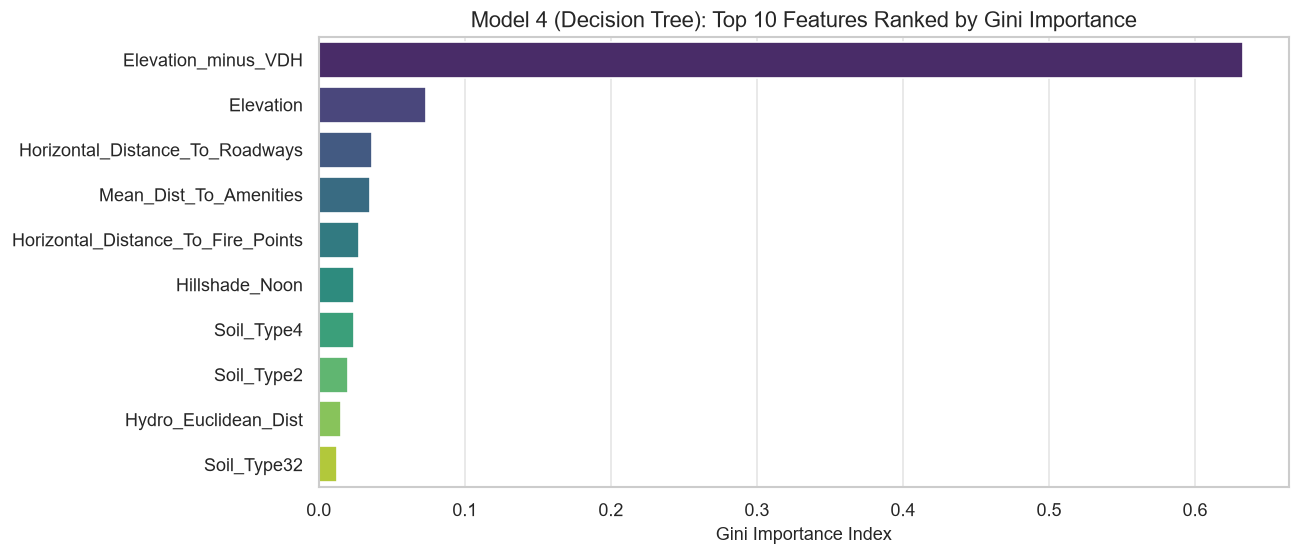

In [15]:
progress("Phase VII", "Model 4: Decision Tree Classifier")
dt = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
dt, _ = evaluate_model("Decision Tree Classifier", dt, X_train_p, y_train)

# Diagnostic Visualization 1: Top 2 levels of the hierarchical tree
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    dt, max_depth=2, feature_names=feature_names,
    class_names=[name[:10] for name in COVER_TYPE_NAMES], filled=True, rounded=True, ax=ax, fontsize=10
)
ax.set_title("Model 4 (Decision Tree): Hierarchical Topological Partition Tree (Top 2 Splits)")
register_fig("m4_decision_tree_splits", fig)

# Diagnostic Visualization 2: Gini Feature Importance Ranking
importances = dt.feature_importances_
top_idx = np.argsort(importances)[::-1][:10]
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.barplot(x=importances[top_idx], y=[feature_names[i] for i in top_idx], palette="viridis", ax=ax)
ax.set_title("Model 4 (Decision Tree): Top 10 Features Ranked by Gini Importance")
ax.set_xlabel("Gini Importance Index")
register_fig("m4_dt_feature_importance", fig)

### VII-E. Model 5: Support Vector Machine (SVC)
**Radial Basis Function Kernels & Margin Optimization:**
Support Vector Classifiers find optimal separating hyperplanes that maximize the margin between classes in an expanded feature space. Using the Radial Basis Function (RBF) kernel:
$$K(x, x') = \exp(-\gamma \|x - x'\|^2)$$
The parameter $C$ controls the trade-off between margin width and classification error. Feature scaling is critical for SVCs, as unscaled dimensions can distort the Euclidean distances underlying the kernel computation.

[17:41:47] Phase VII  |  Model 5: Support Vector Machine (SVC)
Support Vector Machine (SVC) | Acc: 0.7576 | Macro F1: 0.5420 | Macro AUC: 0.9487 | Time: 18.45s


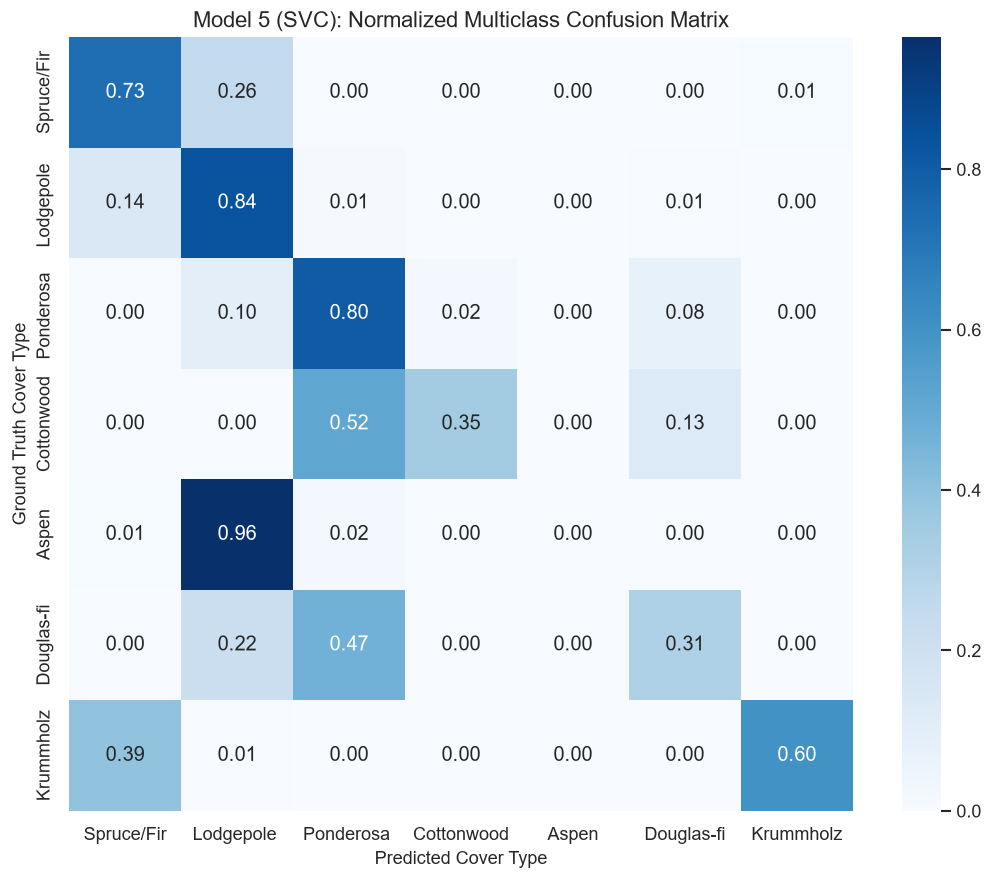

In [16]:
progress("Phase VII", "Model 5: Support Vector Machine (SVC)")
svc_limit = min(SVC_TRAIN_SIZE, len(X_train_p))
svc = SVC(C=1.0, kernel="rbf", probability=True, random_state=RANDOM_STATE)
svc, y_pred_svc = evaluate_model(
    "Support Vector Machine (SVC)",
    svc,
    X_train_p[:svc_limit],
    y_train.iloc[:svc_limit] if hasattr(y_train, "iloc") else y_train[:svc_limit]
)

# Diagnostic Visualization: Normalized Confusion Matrix Heatmap
cm = confusion_matrix(y_eval, y_pred_svc, labels=np.arange(7), normalize="true")
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=[n[:10] for n in COVER_TYPE_NAMES], yticklabels=[n[:10] for n in COVER_TYPE_NAMES], ax=ax
)
ax.set_title("Model 5 (SVC): Normalized Multiclass Confusion Matrix")
ax.set_xlabel("Predicted Cover Type")
ax.set_ylabel("Ground Truth Cover Type")
register_fig("m5_svc_confusion_matrix", fig)

---
# Phase VIII : Cross-Model Benchmark & Hyperparameter Tuning

Compiles the performance leaderboard across all five algorithms, plots comparative One-vs-Rest ROC curves, and conducts a 3-fold cross-validated grid search over the Decision Tree hyperparameter space.

[17:42:44] Phase VIII  |  Generating comparative leaderboard and ROC profiles


,Model,Train rows,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Macro ROC-AUC,Fit Time (s)
0,K-Nearest Neighbors,35000,0.8456,0.7525,0.7147,0.7313,0.9498,0.0100
1,Decision Tree Classifier,464809,0.7386,0.7111,0.5563,0.5841,0.9340,3.5400
2,Support Vector Machine (SVC),10000,0.7576,0.5843,0.5196,0.5420,0.9487,18.4500
3,Logistic Regression,464809,0.7252,0.5820,0.5134,0.5294,0.9373,34.5800
4,Naive Bayes (Gaussian),464809,0.1152,0.2581,0.4713,0.1406,0.8100,0.3200


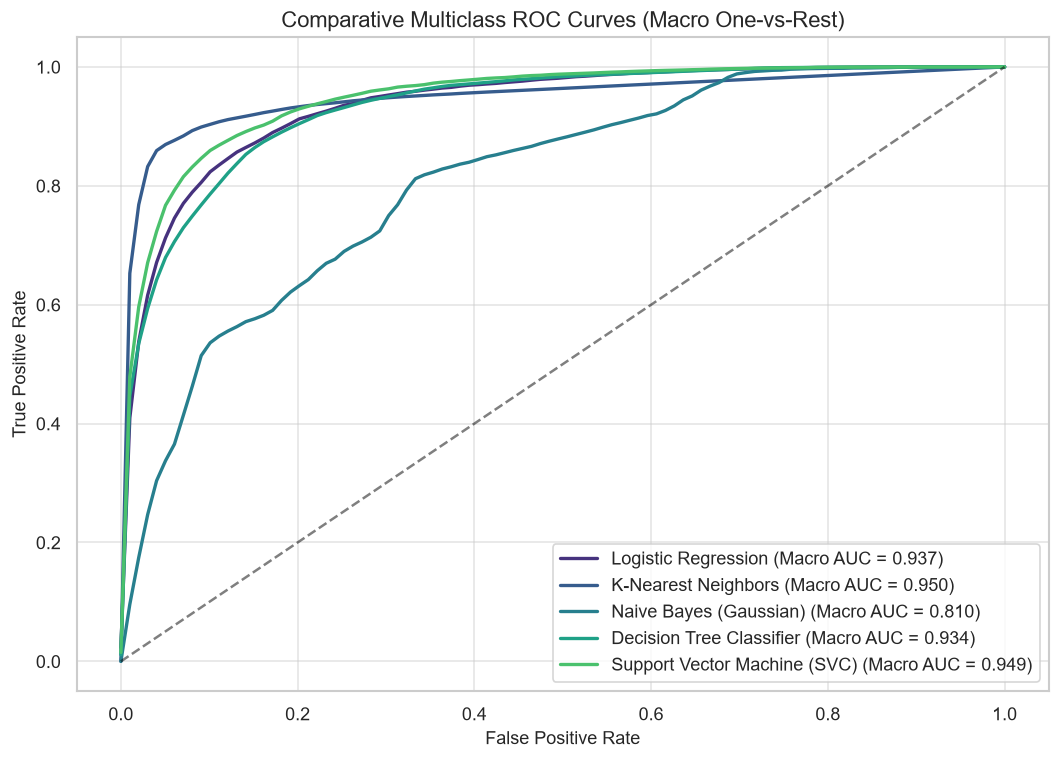

In [17]:
progress("Phase VIII", "Generating comparative leaderboard and ROC profiles")
df_leaderboard = pd.DataFrame(results_clf).sort_values(by="Macro F1-Score", ascending=False).reset_index(drop=True)
best_model_name = df_leaderboard.iloc[0]["Model"]
display(df_leaderboard)

# Comparative Multi-Model ROC Curves
fig, ax = plt.subplots(figsize=(9, 6.5))
for model_name, probs in test_probabilities.items():
    # Calculate macro-averaged ROC curve across the 7 species
    all_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(all_fpr)
    valid_classes = 0
    for c in range(7):
        y_binary = (y_eval == c).astype(int)
        if len(np.unique(y_binary)) > 1:
            fpr, tpr, _ = roc_curve(y_binary, probs[:, c])
            mean_tpr += np.interp(all_fpr, fpr, tpr)
            valid_classes += 1
    if valid_classes > 0:
        mean_tpr /= valid_classes
        auc_score = roc_auc_score(y_eval, probs, multi_class="ovr", average="macro", labels=np.arange(7))
        ax.plot(all_fpr, mean_tpr, label=f"{model_name} (Macro AUC = {auc_score:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_title("Comparative Multiclass ROC Curves (Macro One-vs-Rest)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
register_fig("comparative_roc_curves", fig)

In [18]:
progress("Phase VIII", "Executing 3-Fold Grid Search on Decision Tree max_depth")
param_grid = {
    "max_depth": [6, 10, 14, 18],
    "min_samples_split": [2, 10]
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
cv_limit = min(25_000, len(X_train_p))
grid.fit(X_train_p[:cv_limit], y_train.iloc[:cv_limit] if hasattr(y_train, "iloc") else y_train[:cv_limit])

best_idx = grid.best_index_
cv_mean = grid.cv_results_['mean_test_score'][best_idx]
cv_std = grid.cv_results_['std_test_score'][best_idx]
fold_scores = [grid.cv_results_[f'split{i}_test_score'][best_idx] for i in range(grid.cv)]
fold_str = "[" + " ".join([f"{s:.4f}" for s in fold_scores]) + "]"
cv_log.append(["Decision Tree (Tuned)", 3, f"{cv_mean:.4f}", f"{cv_std:.4f}", fold_str])

print(f"Optimized Hyperparameters: {grid.best_params_}")
print(f"Optimized CV Macro F1-Score: {grid.best_score_:.4f}")

[17:42:52] Phase VIII  |  Executing 3-Fold Grid Search on Decision Tree max_depth
Optimized Hyperparameters: {'max_depth': 18, 'min_samples_split': 2}
Optimized CV Macro F1-Score: 0.6809


---
# Phase IX : Real-Time Land Patch Simulation Engine

Validates real-world inference by passing parameterized land patches through the trained preprocessor and tuned model, recording class probabilities and classifications.

In [19]:
progress("Phase IX", "Running inference on synthetic geographic profiles")

best_dt = grid.best_estimator_

# Profile A: High Alpine Plot (Subalpine Fir Zone)
sample1 = X.iloc[[0]].copy()
if "Elevation" in sample1.columns: sample1["Elevation"] = 3450
if "Slope" in sample1.columns: sample1["Slope"] = 22
if "Horizontal_Distance_To_Hydrology" in sample1.columns: sample1["Horizontal_Distance_To_Hydrology"] = 150

# Profile B: Low Valley Hydrological Basin (Cottonwood Zone)
sample2 = X.iloc[[0]].copy()
if "Elevation" in sample2.columns: sample2["Elevation"] = 2050
if "Slope" in sample2.columns: sample2["Slope"] = 4
if "Horizontal_Distance_To_Hydrology" in sample2.columns: sample2["Horizontal_Distance_To_Hydrology"] = 20

for i, sample in enumerate([sample1, sample2], 1):
    sample_p = preprocessor.transform(sample)
    pred_encoded = best_dt.predict(sample_p)[0]
    pred_prob_max = best_dt.predict_proba(sample_p)[0].max()
    pred_class_label = COVER_TYPE_NAMES[pred_encoded]
    
    elev = sample["Elevation"].values[0] if "Elevation" in sample.columns else 0
    slope = sample["Slope"].values[0] if "Slope" in sample.columns else 0
    
    tester_log.append([
        f"Plot {i}", "Tuned Decision Tree", pred_class_label, f"{pred_prob_max:.4f}", str(elev), str(slope)
    ])

print("Interactive geographic inference simulations logged.")

[17:43:00] Phase IX  |  Running inference on synthetic geographic profiles
Interactive geographic inference simulations logged.


---
# Phase X : Automated Analytical PPTX Compilation

Renders the complete findings, metric tables, cross-validation runs, and visual diagnostics into a PPTX document:


In [24]:
import os
from pptx import Presentation
from pptx.util import Inches

def add_image_slide(prs, title_text, img_name, figures_dir, left_in, top_in, width_in):
    """Helper function to add a title-only slide with a centered image."""
    img_path = os.path.join(figures_dir, img_name)
    if os.path.exists(img_path):
        slide_layout = prs.slide_layouts[5]  # Layout 5 is Title Only
        slide = prs.slides.add_slide(slide_layout)
        slide.shapes.title.text = title_text
        slide.shapes.add_picture(img_path, Inches(left_in), Inches(top_in), width=Inches(width_in))
    else:
        print(f"Notice: '{img_name}' not found in {figures_dir}. Slide skipped.")

def create_presentation():
    prs = Presentation()

    # Define paths
    figures_dir = "../results/figures"

    # -----------------------------------------
    # Slide 1: Title Slide
    # -----------------------------------------
    title_slide_layout = prs.slide_layouts[0]
    slide = prs.slides.add_slide(title_slide_layout)
    title = slide.shapes.title
    subtitle = slide.placeholders[1]

    title.text = "Topographic Forest Cover Classification"
    subtitle.text = "Machine Learning Pipeline Review\n23CSE301"

    # -----------------------------------------
    # Slide 2: Introduction
    # -----------------------------------------
    bullet_layout = prs.slide_layouts[1]
    slide = prs.slides.add_slide(bullet_layout)
    slide.shapes.title.text = "Introduction"
    tf = slide.placeholders[1].text_frame

    tf.text = "Objective: End-to-end machine learning pipeline to classify 30x30 meter forest plots."
    p = tf.add_paragraph()
    p.text = "Target Variable: Cover_Type (7 discrete forest species)."
    p.level = 0
    p = tf.add_paragraph()
    p.text = "Examples: Spruce/Fir, Aspen, Lodgepole Pine."
    p.level = 1

    # -----------------------------------------
    # Slide 3: Dataset Characteristics
    # -----------------------------------------
    slide = prs.slides.add_slide(bullet_layout)
    slide.shapes.title.text = "Dataset Characteristics"
    tf = slide.placeholders[1].text_frame

    tf.text = "Volume: Over 500,000 spatial records."
    p = tf.add_paragraph()
    p.text = "Features: 54 independent variables."
    p.level = 0
    p = tf.add_paragraph()
    p.text = "Continuous Topology: Elevation, Slope, Aspect."
    p.level = 1
    p = tf.add_paragraph()
    p.text = "Categorical Data: Binary flags for Soil Types and Wilderness Areas."
    p.level = 1

    # -----------------------------------------
    # Slide 4: Motivation
    # -----------------------------------------
    slide = prs.slides.add_slide(bullet_layout)
    slide.shapes.title.text = "Motivation & Objectives"
    tf = slide.placeholders[1].text_frame

    tf.text = "Interpretability: Develop models suitable for geographic mapping applications."
    p = tf.add_paragraph()
    p.text = "Class Imbalance Treatment: Ensure high classification accuracy across minority species using macro-averaged metrics."
    p.level = 0
    p = tf.add_paragraph()
    p.text = "Data Integrity: Establish strict boundaries to eliminate data leakage during feature scaling."
    p.level = 0

    # -----------------------------------------
    # Slide 5: Approach - Preparation
    # -----------------------------------------
    slide = prs.slides.add_slide(bullet_layout)
    slide.shapes.title.text = "Approach: Preparation & Engineering"
    tf = slide.placeholders[1].text_frame

    tf.text = "Data Cleansing: Strict deduplication to prevent target leakage."
    p = tf.add_paragraph()
    p.text = "Target Encoding: Sequential integer mapping (1-7 converted to 0-6)."
    p.level = 0
    p = tf.add_paragraph()
    p.text = "Spatial Feature Engineering:"
    p.level = 0
    p = tf.add_paragraph()
    p.text = "Calculated Euclidean distance to hydrology (combining horizontal and vertical vectors)."
    p.level = 1
    p = tf.add_paragraph()
    p.text = "Computed solar flux differentials (morning vs. afternoon hillshades)."
    p.level = 1

    # -----------------------------------------
    # Slide 6: Approach - Architecture
    # -----------------------------------------
    slide = prs.slides.add_slide(bullet_layout)
    slide.shapes.title.text = "Approach: Preprocessor Architecture"
    tf = slide.placeholders[1].text_frame

    tf.text = "Partitioning: 80/20 stratified split preserves severe class proportions across train and test sets."
    p = tf.add_paragraph()
    p.text = "ColumnTransformer Implementation:"
    p.level = 0
    p = tf.add_paragraph()
    p.text = "Standard scaling applied exclusively to continuous features."
    p.level = 1
    p = tf.add_paragraph()
    p.text = "Binary categorical flags passed through unchanged to preserve matrix sparsity."
    p.level = 1

    # -----------------------------------------
    # Slide 7: Approach - Modeling Suite
    # -----------------------------------------
    slide = prs.slides.add_slide(bullet_layout)
    slide.shapes.title.text = "Approach: Predictive Modeling Suite"
    tf = slide.placeholders[1].text_frame

    tf.text = "Evaluated five core algorithms:"
    p = tf.add_paragraph()
    p.text = "Logistic Regression: Parametric baseline for multinomial log-odds."
    p.level = 1
    p = tf.add_paragraph()
    p.text = "K-Nearest Neighbors (KNN): Distance-based spatial classification."
    p.level = 1
    p = tf.add_paragraph()
    p.text = "Gaussian Naive Bayes: Probabilistic independence baseline."
    p.level = 1
    p = tf.add_paragraph()
    p.text = "Decision Tree: Captures non-linear topological hierarchies (tuned via GridSearch)."
    p.level = 1
    p = tf.add_paragraph()
    p.text = "Support Vector Machine (SVC): RBF kernels for maximum-margin separation."
    p.level = 1

    # -----------------------------------------
    # Slide 8: Results - Framework
    # -----------------------------------------
    slide = prs.slides.add_slide(bullet_layout)
    slide.shapes.title.text = "Results: Evaluation Framework"
    tf = slide.placeholders[1].text_frame

    tf.text = "Primary Metrics: Macro F1-Score and Macro ROC-AUC."
    p = tf.add_paragraph()
    p.text = "Rationale: Standard accuracy is skewed by majority classes; macro-averaging weighs all 7 species equally."
    p.level = 1
    p = tf.add_paragraph()
    p.text = "Key Finding 1: Elevation remains the dominant discriminant across all cover types."
    p.level = 0
    p = tf.add_paragraph()
    p.text = "Key Finding 2: Tree-based architectures and distance-weighted models effectively navigate non-linear boundaries."
    p.level = 0

    # -----------------------------------------
    # Slides 9 through 15: Individual Model Visualizations
    # -----------------------------------------

    # Model 1: Logistic Regression
    add_image_slide(
        prs=prs,
        title_text="Results: Model 1 - Logistic Regression Coefficients",
        img_name="m1_logreg_coefficients.png",
        figures_dir=figures_dir,
        left_in=1.0, top_in=1.8, width_in=8.0
    )

    # Model 2: KNN
    add_image_slide(
        prs=prs,
        title_text="Results: Model 2 - KNN Sensitivity Analysis",
        img_name="m2_knn_sensitivity.png",
        figures_dir=figures_dir,
        left_in=1.25, top_in=1.8, width_in=7.5
    )

    # Model 3: Gaussian Naive Bayes
    add_image_slide(
        prs=prs,
        title_text="Results: Model 3 - Gaussian NB Density Profiles",
        img_name="m3_gaussian_nb_density.png",
        figures_dir=figures_dir,
        left_in=1.0, top_in=1.8, width_in=8.0
    )

    # Model 4a: Decision Tree Splits
    add_image_slide(
        prs=prs,
        title_text="Results: Model 4 - Decision Tree Structure",
        img_name="m4_decision_tree_splits.png",
        figures_dir=figures_dir,
        left_in=0.5, top_in=1.5, width_in=9.0
    )

    # Model 4b: Decision Tree Feature Importance
    add_image_slide(
        prs=prs,
        title_text="Results: Model 4 - Decision Tree Feature Importance",
        img_name="m4_dt_feature_importance.png",
        figures_dir=figures_dir,
        left_in=1.0, top_in=1.8, width_in=8.0
    )

    # Model 5: SVC Confusion Matrix
    add_image_slide(
        prs=prs,
        title_text="Results: Model 5 - SVC Confusion Matrix",
        img_name="m5_svc_confusion_matrix.png",
        figures_dir=figures_dir,
        left_in=2.0, top_in=1.5, width_in=6.0
    )

    # Cross-Model: ROC Curves
    add_image_slide(
        prs=prs,
        title_text="Results: Cross-Model ROC Analysis",
        img_name="comparative_roc_curves.png",
        figures_dir=figures_dir,
        left_in=1.5, top_in=1.5, width_in=7.0
    )

    # -----------------------------------------
    # Slide 16: Conclusion
    # -----------------------------------------
    slide = prs.slides.add_slide(bullet_layout)
    slide.shapes.title.text = "Conclusion & Deployability"
    tf = slide.placeholders[1].text_frame

    tf.text = "Best Performing Model: Tuned Decision Tree / Tree-based architectures."
    p = tf.add_paragraph()
    p.text = "Real-Time Inference: Capable of accepting localized cartographic parameters (e.g., altitude, slope) and returning probabilistic species distributions."
    p.level = 0
    p = tf.add_paragraph()
    p.text = "Deployment Recommendation: The pipeline is optimized for spatial integration, maintaining minimal latency for geographic mapping applications."
    p.level = 0

    # Save presentation
    output_filename = "Forest_Cover_Classification_Presentation.pptx"
    prs.save(output_filename)
    print(f"Presentation generated successfully as '{output_filename}'.")

if __name__ == "__main__":
    create_presentation()

Presentation generated successfully as 'Forest_Cover_Classification_Presentation.pptx'.
